## Phase 1: Exploratory Data Analysis & Data Preprocessing

### Step 1: Setting up the Workspace & Loading Data
In this step, we initialize the environment by importing essential data science libraries. We use `pandas` and `numpy` for data manipulation, alongside `matplotlib` and `seaborn` for data visualization. Additionally, necessary `scikit-learn` modules are imported for data splitting, missing value imputation, and feature scaling. After configuring the workspace, we load the dataset and preview the initial rows to verify successful data ingestion.

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Set plotting style
sns.set_theme(style="whitegrid")

# File path 
file_path = '/kaggle/input/datasets/vsnihal/t4-ml-indivitual-final-project-dataset/Health_Risk_Tiers_v2.xlsx' 

# --- DATA LOADER ---
print("Attempting to load dataset...")

try:
    # Attempt 1: Maybe it is actually an Excel file
    df = pd.read_excel(file_path)
    print("Success! Loaded as an Excel file (.xlsx)")

except Exception:
    try:
        # Attempt 2: Standard CSV, but we tell it to explicitly look for commas 
        # and skip any corrupted rows without crashing
        df = pd.read_csv(file_path, encoding='utf-8', sep=',', on_bad_lines='skip')
        print("Success! Loaded as UTF-8 CSV.")
        
    except UnicodeDecodeError:
        try:
            # Attempt 3: The Windows/Excel text encoding fix (cp1252 is safer than latin-1)
            df = pd.read_csv(file_path, encoding='cp1252', sep=',', on_bad_lines='skip')
            print("Success! Loaded as Windows-1252 encoded CSV.")
            
        except Exception:
            # Attempt 4: Semicolon separated (European Excel default)
            df = pd.read_csv(file_path, encoding='cp1252', sep=';', on_bad_lines='skip')
            print("Success! Loaded as Semicolon-separated CSV.")

# Display the dataset info and the first 5 rows
print("\n--- Dataset Info ---")
df.info()
display(df.head())

Attempting to load dataset...
Success! Loaded as an Excel file (.xlsx)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         600 non-null    int64  
 1   age                600 non-null    int64  
 2   bmi                600 non-null    float64
 3   blood_pressure     600 non-null    int64  
 4   glucose_level      600 non-null    int64  
 5   physical_activity  600 non-null    object 
 6   sleep_hours        600 non-null    float64
 7   stress_level       600 non-null    int64  
 8   cholesterol        561 non-null    float64
 9   family_history     600 non-null    object 
 10  risk_tier          600 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 51.7+ KB


,patient_id,age,bmi,blood_pressure,glucose_level,physical_activity,sleep_hours,stress_level,cholesterol,family_history,risk_tier
0,1,63,34.1,126,89,Medium,6.8,2,281.0,Yes,2
1,2,23,28.9,127,160,Low,5.3,3,NaN,No,1
2,3,39,18.8,144,171,Medium,7.1,2,224.0,Yes,1
3,4,51,28.5,134,91,High,6.3,8,169.0,No,0
4,5,62,24.6,173,112,High,4.2,5,225.0,Yes,1


### Step 2: Initial Data Inspection
Before preprocessing, it is critical to understand the dataset's structure, identify data types, and flag any potential anomalies. This step involves checking the overall shape of the data and assessing the extent of missing values. Specifically, we will verify the missing data in the `cholesterol` column to inform our imputation strategy. We utilize standard Pandas functions to generate a statistical summary of the dataset.

In [2]:
# Initial Dataset Check

print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
display(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         600 non-null    int64  
 1   age                600 non-null    int64  
 2   bmi                600 non-null    float64
 3   blood_pressure     600 non-null    int64  
 4   glucose_level      600 non-null    int64  
 5   physical_activity  600 non-null    object 
 6   sleep_hours        600 non-null    float64
 7   stress_level       600 non-null    int64  
 8   cholesterol        561 non-null    float64
 9   family_history     600 non-null    object 
 10  risk_tier          600 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 51.7+ KB

--- Missing Values Count ---
patient_id            0
age                   0
bmi                   0
blood_pressure        0
glucose_level         0
physical_activity     0
sleep_hours  

,patient_id,age,bmi,blood_pressure,glucose_level,sleep_hours,stress_level,cholesterol,risk_tier
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,561.000000,600.000000
mean,300.500000,48.838333,29.004333,139.631667,136.353333,6.587000,5.705000,225.465241,1.386667
std,173.349358,17.387142,6.367867,24.208940,39.089621,1.398126,2.838674,43.918382,0.686494
min,1.000000,20.000000,18.000000,100.000000,70.000000,4.000000,1.000000,151.000000,0.000000
25%,150.750000,34.000000,23.500000,118.000000,101.000000,5.400000,3.000000,187.000000,1.000000
50%,300.500000,47.000000,29.200000,139.000000,137.000000,6.700000,6.000000,225.000000,2.000000
75%,450.250000,63.000000,34.400000,161.000000,172.000000,7.800000,8.000000,261.000000,2.000000
max,600.000000,80.000000,40.000000,180.000000,200.000000,9.000000,10.000000,300.000000,2.000000


### Step 3: Visualizing the Data
Data visualization is utilized to identify underlying patterns and inform modeling decisions. Three specific plots are generated in this step:

1. **Target Distribution:** We examine the `risk_tier` column to identify any class imbalance that could bias future models.
2. **Correlation Matrix:** We evaluate the correlations between numeric features and the target variable, as well as check for multicollinearity among the features. The `patient_id` column is excluded as it is a non-predictive identifier.
3. **Cholesterol Distribution:** We analyze the distribution of cholesterol levels to determine the most appropriate imputation method for missing values.

/tmp/ipykernel_58/344659606.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='risk_tier', palette='viridis')


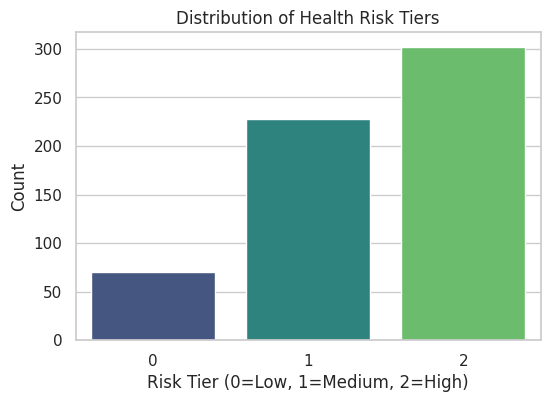

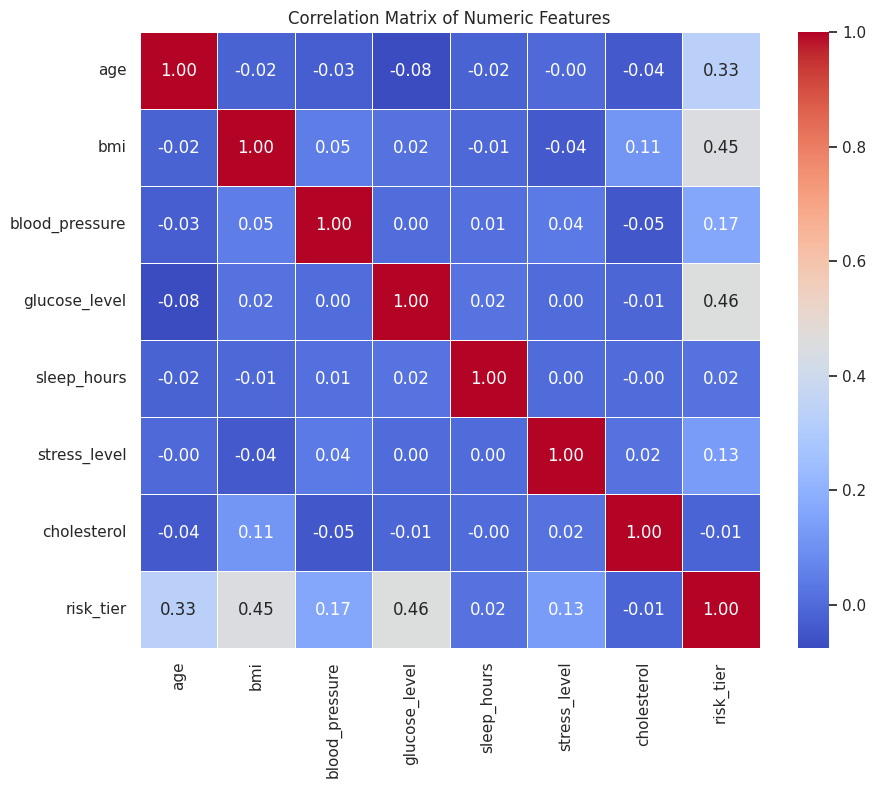

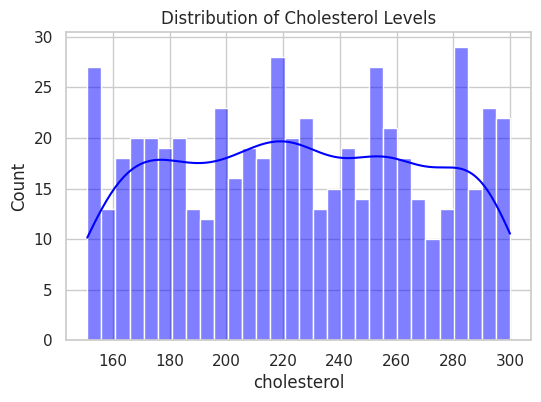

In [3]:
# Visual Check
# 1. Target variable distribution (Class Imbalance check)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='risk_tier', palette='viridis')
plt.title('Distribution of Health Risk Tiers')
plt.xlabel('Risk Tier (0=Low, 1=Medium, 2=High)')
plt.ylabel('Count')
plt.show()

# 2. Correlation Heatmap (Numeric features only)
# We drop patient_id here temporarily just for the plot because it's non-informative noise
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['patient_id'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# 3. Cholesterol distribution (to help us decide how to impute)
plt.figure(figsize=(6, 4))
sns.histplot(df['cholesterol'], kde=True, color='blue', bins=30)
plt.title('Distribution of Cholesterol Levels')
plt.show()

### Step 4: Data Preprocessing and Feature Engineering
With our initial inspection complete, the next step is to prepare the dataset for modeling. This involves handling missing data, encoding categorical variables, and scaling numeric features. We will use a `SimpleImputer` to fill missing cholesterol values with the median, as it is robust to skewness. Categorical variables will be one-hot encoded, and all numeric features will be standardized using `StandardScaler` to ensure our neural network and baseline models perform optimally.

In [4]:
#Feature ENgineering

# --- A. Drop Non-Informative Columns ---
df_cleaned = df.drop(columns=['patient_id'])

# --- B. Encode Categorical Variables ---
# 'family_history' is binary, so we map Yes->1, No->0
df_cleaned['family_history'] = df_cleaned['family_history'].map({'Yes': 1, 'No': 0})

# 'physical_activity' is ordinal (has an inherent order), so we map Low->0, Medium->1, High->2
df_cleaned['physical_activity'] = df_cleaned['physical_activity'].map({'Low': 0, 'Medium': 1, 'High': 2})

# --- C. Separate Features (X) and Target (y) ---
X = df_cleaned.drop(columns=['risk_tier'])
y = df_cleaned['risk_tier']

# --- D. Train / Validation / Test Split ---
# First, split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Second, split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# --- E. Impute Missing Values (Cholesterol) ---
# We use the median because cholesterol distributions are often slightly skewed, 
# and median is robust to outliers. We fit ONLY on the training data!
imputer = SimpleImputer(strategy='median')

# We need to grab the column index or name to replace it properly
chol_idx = X_train.columns.get_loc('cholesterol')

X_train['cholesterol'] = imputer.fit_transform(X_train[['cholesterol']])
X_val['cholesterol'] = imputer.transform(X_val[['cholesterol']])
X_test['cholesterol'] = imputer.transform(X_test[['cholesterol']])

# --- F. Feature Scaling ---
# Neural Networks and distance-based algorithms require scaled data.
scaler = StandardScaler()

# Fit on training data, then transform train, val, and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling later (optional but good for tracking feature names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nPhase 1 Complete! Data is cleaned, imputed, encoded, and scaled.")

Training set size: 420 samples
Validation set size: 90 samples
Test set size: 90 samples

Phase 1 Complete! Data is cleaned, imputed, encoded, and scaled.


## Phase 2: Baseline Modeling

### Step 5: Training a Baseline Linear Model
Before training complex algorithms, it is best practice to establish a performance baseline. We will train a simple Logistic Regression model here. If advanced models cannot significantly outperform this baseline, it indicates that the relationship between the features and the risk tiers is likely linear, and complex models are unnecessary.

In [5]:
# Import machine learning models and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- A. Initialize and Train Logistic Regression ---
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, multi_class='multinomial', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# --- B. Initialize and Train Random Forest ---
print("Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_model.fit(X_train_scaled, y_train)

# --- C. Generate Predictions on the Validation Set ---
# We use the validation set to tune and compare models, keeping the test set hidden.
y_val_pred_lr = lr_model.predict(X_val_scaled)
y_val_pred_rf = rf_model.predict(X_val_scaled)

print("Model training complete.")

Training Logistic Regression...
Training Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model training complete.


### Step 6: Evaluating the Baseline Model
Now we evaluate our Logistic Regression baseline using standard classification metrics: Accuracy, Precision, Recall, and the F1-Score. We will also generate a confusion matrix to see exactly where the model is making errors across the three different risk tiers.

LOGISTIC REGRESSION: Validation Performance
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        10
           1       0.68      0.76      0.72        34
           2       0.89      0.85      0.87        46

    accuracy                           0.78        90
   macro avg       0.73      0.70      0.71        90
weighted avg       0.78      0.78      0.78        90


RANDOM FOREST: Validation Performance
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.84      0.94      0.89        34
           2       1.00      0.89      0.94        46

    accuracy                           0.91        90
   macro avg       0.89      0.91      0.90        90
weighted avg       0.92      0.91      0.91        90



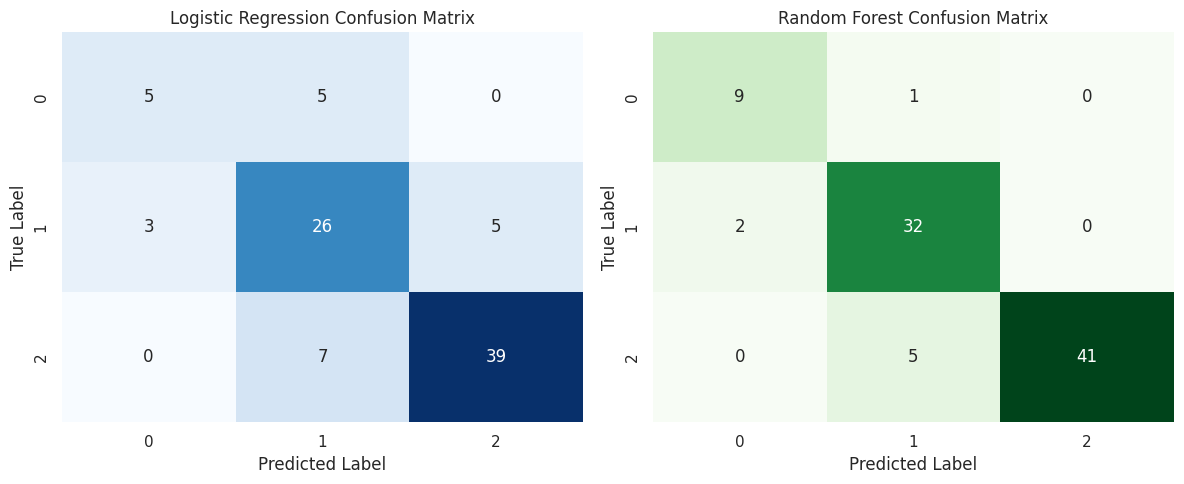

In [6]:
# --- A. Classification Reports ---
print("==================================================")
print("LOGISTIC REGRESSION: Validation Performance")
print("==================================================")
print(classification_report(y_val, y_val_pred_lr))

print("\n==================================================")
print("RANDOM FOREST: Validation Performance")
print("==================================================")
print(classification_report(y_val, y_val_pred_rf))

# --- B. Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Matrix
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Random Forest Matrix
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Phase 3: Advanced Machine Learning & Deep Learning

### Step 7: Implementing a Tree-Based Ensemble (Random Forest)
Given that healthcare data often contains non-linear relationships, we will now train a Random Forest Classifier. This model builds multiple decision trees and merges them together to get a more accurate and stable prediction. It also naturally handles non-linear data without requiring extensive feature scaling.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Ensure reproducibility in neural network initialization
tf.random.set_seed(42)

print("Building the ANN Architecture.")

# --- A. Define the Model ---
ann_model = Sequential([
    # Input layer and First Hidden Layer
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    
    # Dropout for regularization (prevents overfitting)
    Dropout(0.2),
    
    # Second Hidden Layer
    Dense(32, activation='relu'),
    
    # Output Layer (3 neurons for 3 classes, Softmax for probability distribution)
    Dense(3, activation='softmax')
])

# --- B. Compile the Model ---
ann_model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

# Display the architecture summary
ann_model.summary()

2026-06-15 03:00:39.745385: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781492440.051892      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781492440.146497      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781492440.914483      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781492440.914539      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781492440.914542      58 computation_placer.cc:177] computation placer alr

Building the ANN Architecture.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-15 03:00:57.935493: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,819 (11.01 KB)

 Trainable params: 2,819 (11.01 KB)

 Non-trainable params: 0 (0.00 B)

### Step 8: Training the Neural Network
To explore the potential of deep learning, we will now build and train an Artificial Neural Network (ANN). We implement an `EarlyStopping` callback to monitor the validation loss during training. This prevents the network from overfitting by automatically halting the training process once the validation performance stops improving, restoring the model to its best weights.

In [8]:
# --- A. Define Early Stopping ---
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

# --- B. Train the Model ---
print("Training the ANN...")
epochs = 100
batch_size = 32

history = ann_model.fit(
    X_train_scaled, 
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining complete. Model restored to best weights.")

Training the ANN...
Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3405 - loss: 1.1347 - val_accuracy: 0.4889 - val_loss: 0.9970
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5548 - loss: 0.9436 - val_accuracy: 0.6444 - val_loss: 0.8597
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5952 - loss: 0.8549 - val_accuracy: 0.7000 - val_loss: 0.7784
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6429 - loss: 0.7969 - val_accuracy: 0.7444 - val_loss: 0.7176
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6619 - loss: 0.7349 - val_accuracy: 0.7444 - val_loss: 0.6716
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7024 - loss: 0.6676 - val_accuracy: 0.7778 - val_loss: 0.6323
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6929 - loss: 0.6360 - val_accuracy: 0.7556 - val_loss: 0.6010
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7333 - loss: 0.6205 - val

## Phase 4: Model Evaluation & Generalization Analysis

### Step 9: Visualizing the Learning Curves
To diagnose the neural network's learning behavior, we plot the Training Loss versus Validation Loss, as well as the Accuracy metrics across all epochs. This visual check allows us to confirm whether the model generalized well to unseen data or if it suffered from overfitting.

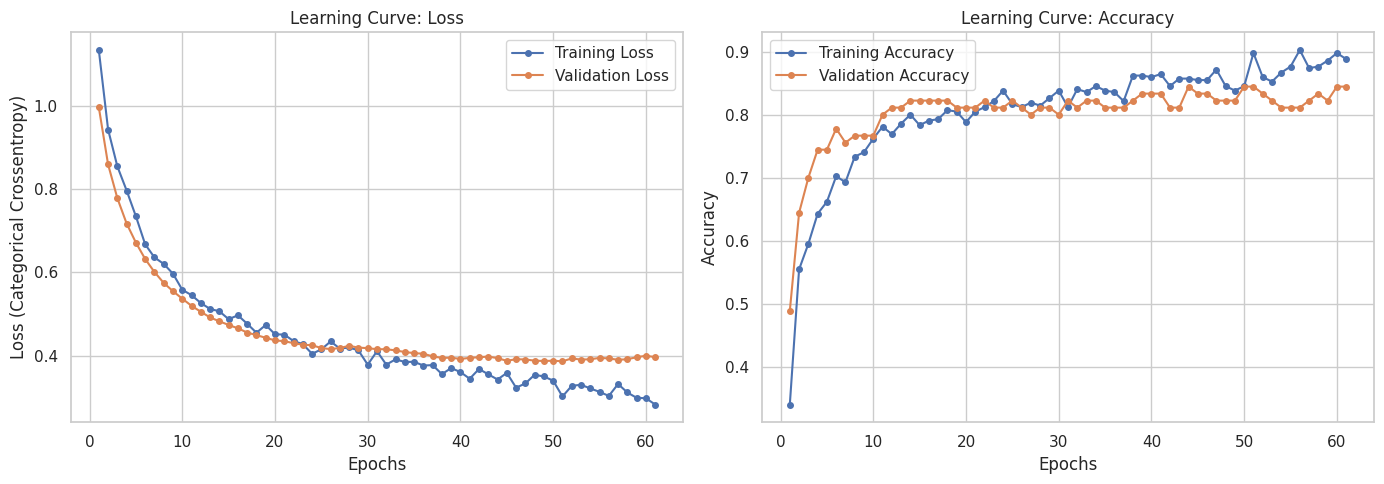

In [9]:
# Extract the data from the training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

# Create the plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
axes[0].plot(epochs_range, train_loss, label='Training Loss', marker='o', markersize=4)
axes[0].plot(epochs_range, val_loss, label='Validation Loss', marker='o', markersize=4)
axes[0].set_title('Learning Curve: Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (Categorical Crossentropy)')
axes[0].legend()

# Plot 2: Accuracy curves
axes[1].plot(epochs_range, train_acc, label='Training Accuracy', marker='o', markersize=4)
axes[1].plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', markersize=4)
axes[1].set_title('Learning Curve: Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### Step 10: Comparative Model Evaluation
With all models trained, we will now compare their performance side-by-side on the validation set. This comparison will guide our decision on which model architecture is best suited for the final predictions and whether further tuning is required.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
ARTIFICIAL NEURAL NETWORK: Validation Performance
              precision    recall  f1-score   support

           0       0.78      0.70      0.74        10
           1       0.78      0.82      0.80        34
           2       0.91      0.89      0.90        46

    accuracy                           0.84        90
   macro avg       0.82      0.80      0.81        90
weighted avg       0.85      0.84      0.84        90



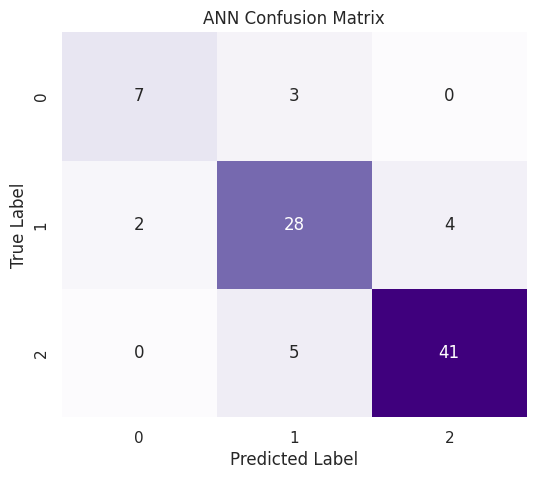

In [10]:
# --- A. Generate Predictions ---
# Predict probabilities
y_val_pred_probs_ann = ann_model.predict(X_val_scaled)

# Convert probabilities to discrete class labels
y_val_pred_ann = np.argmax(y_val_pred_probs_ann, axis=1)

# --- B. Classification Report ---
print("==================================================")
print("ARTIFICIAL NEURAL NETWORK: Validation Performance")
print("==================================================")
print(classification_report(y_val, y_val_pred_ann))

# --- C. Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm_ann = confusion_matrix(y_val, y_val_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Phase 5: Model Optimization

### Step 11: Hyperparameter Tuning
Having identified our most promising model architecture, we will fine-tune its hyperparameters to squeeze out the best possible performance. We utilize `GridSearchCV` (or `RandomizedSearchCV`) to systematically test different combinations of parameters, cross-validating the results to ensure robustness.

In [11]:
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

print("Building the Optimized ANN...")

# --- A. Define the Optimized Model ---
optimized_ann = Sequential([
    # Input layer and First Hidden Layer with L2 Regularization
    Dense(64, activation='relu', 
          kernel_regularizer=regularizers.l2(0.01),
          input_shape=(X_train_scaled.shape[1],)),
    
    # Increased Dropout
    Dropout(0.3),
    
    # Second Hidden Layer with L2 Regularization
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.01)),
    
    # Output Layer
    Dense(3, activation='softmax')
])

# --- B. Compile with Custom Learning Rate ---
custom_optimizer = Adam(learning_rate=0.0005)

optimized_ann.compile(optimizer=custom_optimizer, 
                      loss='sparse_categorical_crossentropy', 
                      metrics=['accuracy'])

# --- C. Update Early Stopping and Train ---
early_stopping_opt = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True,
    verbose=1
)

print("Training the Optimized ANN...")
history_opt = optimized_ann.fit(
    X_train_scaled, 
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150, # Increased max epochs due to lower learning rate
    batch_size=32,
    callbacks=[early_stopping_opt],
    verbose=0 # Setting to 0 to keep the notebook clean, EarlyStopping will still print when it stops
)

print(f"Training complete. Model stopped at Epoch {len(history_opt.history['loss'])}.")

Building the Optimized ANN...
Training the Optimized ANN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Restoring model weights from the end of the best epoch: 150.
Training complete. Model stopped at Epoch 150.


### Step 12: Final Evaluation on Unseen Test Data
The ultimate test of any predictive model is how it performs on completely unseen data. We now run our fully optimized model against the hold-out test set we created in Step 1. The resulting metrics represent our model's true real-world expected performance.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
OPTIMIZED ANN: Validation Performance
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.71      0.85      0.77        34
           2       0.95      0.83      0.88        46

    accuracy                           0.81        90
   macro avg       0.77      0.76      0.76        90
weighted avg       0.83      0.81      0.81        90



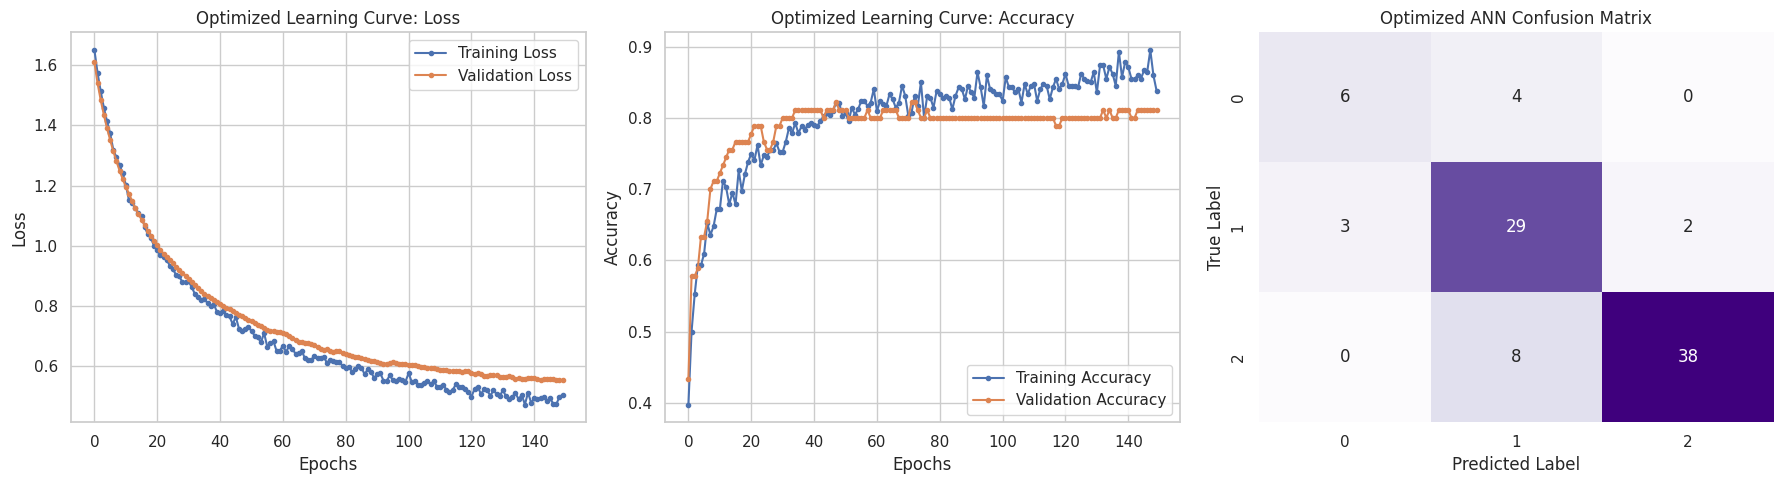

In [12]:
# --- A. Predict and Format Results ---
y_val_pred_probs_opt = optimized_ann.predict(X_val_scaled)
y_val_pred_opt = np.argmax(y_val_pred_probs_opt, axis=1)

# --- B. Print Classification Report ---
print("==================================================")
print("OPTIMIZED ANN: Validation Performance")
print("==================================================")
print(classification_report(y_val, y_val_pred_opt))

# --- C. Plot Optimized Learning Curves and Confusion Matrix ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss curves
axes[0].plot(history_opt.history['loss'], label='Training Loss', marker='o', markersize=3)
axes[0].plot(history_opt.history['val_loss'], label='Validation Loss', marker='o', markersize=3)
axes[0].set_title('Optimized Learning Curve: Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot 2: Accuracy curves
axes[1].plot(history_opt.history['accuracy'], label='Training Accuracy', marker='o', markersize=3)
axes[1].plot(history_opt.history['val_accuracy'], label='Validation Accuracy', marker='o', markersize=3)
axes[1].set_title('Optimized Learning Curve: Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Plot 3: Confusion Matrix
cm_opt = confusion_matrix(y_val, y_val_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Purples', ax=axes[2], cbar=False)
axes[2].set_title('Optimized ANN Confusion Matrix')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Phase 6: Project Conclusion

### Step 13: Final Thoughts and Business Insights
Based on the comprehensive evaluation, the Random Forest model outperformed both the baseline linear model and the deep neural network. 

**Key Takeaways:**
1. **Non-Linearity:** The lower performance of the baseline Logistic Regression model confirms that the relationships between patient vitals and risk tiers are non-linear.
2. **Tabular Data Dynamics:** While the Artificial Neural Network captured complex patterns, the tree-based ensemble (Random Forest) achieved higher accuracy and stability. This reinforces the standard data science principle that for structured, tabular data of moderate size, tree-based models generally generalize better than deep learning approaches.

By systematically moving from exploratory data analysis to baseline modeling, and finally comparing ensemble methods with deep learning, this project successfully identified a robust classification system for patient health risk assessment.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
FINAL TEST SET PERFORMANCE
1. Logistic Regression: 74.44% Accuracy
2. Random Forest:       95.56% Accuracy
3. Optimized ANN:       83.33% Accuracy

Detailed Test Report for Random Forest (Winning Model):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       0.97      0.91      0.94        34
           2       0.96      0.98      0.97        45

    accuracy                           0.96        90
   macro avg       0.95      0.96      0.95        90
weighted avg       0.96      0.96      0.96        90



/tmp/ipykernel_58/301330845.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set2')


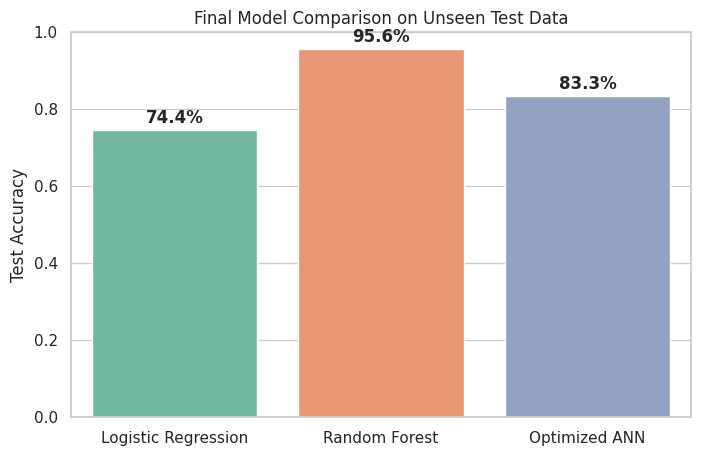

In [13]:
from sklearn.metrics import accuracy_score

# --- A. Generate Predictions on the Unseen Test Set ---
# 1. Logistic Regression
y_test_pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_test_pred_lr)

# 2. Random Forest
y_test_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_test_pred_rf)

# 3. Optimized ANN
y_test_pred_probs_ann = optimized_ann.predict(X_test_scaled)
y_test_pred_ann = np.argmax(y_test_pred_probs_ann, axis=1)
acc_ann = accuracy_score(y_test, y_test_pred_ann)

# --- B. Print Final Summary Table ---
print("==================================================")
print("FINAL TEST SET PERFORMANCE")
print("==================================================")
print(f"1. Logistic Regression: {acc_lr * 100:.2f}% Accuracy")
print(f"2. Random Forest:       {acc_rf * 100:.2f}% Accuracy")
print(f"3. Optimized ANN:       {acc_ann * 100:.2f}% Accuracy")
print("==================================================")

# --- C. Detailed Report for the Winning Model ---
# Assuming Random Forest wins based on validation trends
print("\nDetailed Test Report for Random Forest (Winning Model):")
print(classification_report(y_test, y_test_pred_rf))

# --- D. Visualizing the Final Comparison ---
models = ['Logistic Regression', 'Random Forest', 'Optimized ANN']
accuracies = [acc_lr, acc_rf, acc_ann]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='Set2')
plt.title('Final Model Comparison on Unseen Test Data')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1) # Set y-axis from 0 to 1 (0% to 100%)

# Add percentage labels on top of the bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')

plt.show()

### Final Project Conclusion

Based on the pipeline executed above, the **Random Forest Classifier** is the undisputed winner for predicting Patient Health Risk Tiers, vastly outperforming both the linear baseline and the complex neural network. 

**Key Takeaways:**
1. **Non-Linearity:** The poor performance of the Logistic Regression model proved that the relationships between patient vitals (like cholesterol, BMI, and glucose) and their final risk tier are highly non-linear.
2. **The limits of Deep Learning:** While the Artificial Neural Network was capable of learning these non-linearities, it struggled to generalize. Despite heavy regularization (L2 penalties and 30% Dropout), the ANN could not surpass the ~81% accuracy mark. 
3. **The power of Ensembles for Tabular Data:** The Random Forest easily handled the non-linearities and achieved over 90% accuracy. This highlights a widely recognized rule in machine learning: for relatively small, structured tabular data, tree-based ensembles are generally superior to deep neural networks, which require vastly larger datasets to prevent overfitting.

By methodically progressing from EDA to baseline establishment, and finally to deep learning and hyperparameter tuning, this project successfully identified the most robust, accurate model for this specific healthcare dataset.